### Your name:

<pre> JU ZHANG</pre>

### Collaborators:

<pre> NONE </pre>


# Assignment for Module 4: Clustering

## Description

In this assignment you will study the electric demand (power) of clients in Portugal, during 2013 and 2014.

The data$^1$ available contains 370 time series, corresponding to the electric demand$^2$ for 370 clients, between 2011 and 2014. 

In this guided exercise you will use clustering techniques to understand the typical behaviour during 2013-2014.

#### 1. Data:
https://archive.ics.uci.edu/ml/datasets/ElectricityLoadDiagrams20112014#

#### 2. Electric Demand:
http://www.think-energy.net/KWvsKWH.htm


## Data Preparation

Start by downloading the data to a local directory and modify the "pathToFile" and "fileName" variables, if needed

In [2]:
import os
pathToFile = "./"   ## *** remove hardcoded path, and use relative path instead
fileName = "LD2011_2014.txt"
full_path = os.path.join(pathToFile, fileName)
print(full_path)

./LD2011_2014.txt


In [3]:
import numpy as np
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
import random
from sklearn.metrics import silhouette_score
from sklearn.cluster import AgglomerativeClustering
random.seed(42)

In [4]:
# Replace "," by ".", otherwise the numbers will be in the form 2,3445 instead of 2.3445
import fileinput

with fileinput.FileInput(pathToFile+fileName, inplace=True, backup='.bak') as file:
    for line in file:
        print(line.replace(",", "."), end='')

In [5]:
# Create dataframe
import pandas as pd
data = pd.read_csv(pathToFile+fileName, sep=";", index_col=0)

### Quick data inspection

In [6]:
data.head(2)

,MT_001,MT_002,MT_003,MT_004,MT_005,MT_006,MT_007,MT_008,MT_009,MT_010,...,MT_361,MT_362,MT_363,MT_364,MT_365,MT_366,MT_367,MT_368,MT_369,MT_370
2011-01-01 00:15:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2011-01-01 00:30:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [7]:
data.tail(2)

,MT_001,MT_002,MT_003,MT_004,MT_005,MT_006,MT_007,MT_008,MT_009,MT_010,...,MT_361,MT_362,MT_363,MT_364,MT_365,MT_366,MT_367,MT_368,MT_369,MT_370
2014-12-31 23:45:00,1.269036,21.337127,1.737619,166.666667,85.365854,285.714286,10.17524,225.589226,64.685315,72.043011,...,246.252677,28000.0,1443.037975,909.090909,26.075619,4.095963,664.618086,146.911519,646.627566,6540.540541
2015-01-01 00:00:00,2.538071,19.914651,1.737619,178.861789,84.146341,279.761905,10.17524,249.158249,62.937063,69.892473,...,188.436831,27800.0,1409.282700,954.545455,27.379400,4.095963,628.621598,131.886477,673.020528,7135.135135


In [8]:
data.shape

(140256, 370)

#### As can be seen, the dataframe contains a row for each interval of 15 minutes between Jan 1, 2011 to Dec 31 2014. There are 370 columns corresponding 370 clients. The dataframe is indexed by the timestamp.

Since the frequency is 15 minutes, each day provides $24\times 4 = 96$ datapoints, which multiplied by 365 days and 4 years (plus 1 day in Feb 29, 2012) gives: $96 \times 365 \times 4 + 96 = 140256$, as observed in data.shape

In [9]:
data.info()

<class 'pandas.DataFrame'>
Index: 140256 entries, 2011-01-01 00:15:00 to 2015-01-01 00:00:00
Columns: 370 entries, MT_001 to MT_370
dtypes: float64(370)
memory usage: 397.0+ MB


In [10]:
data.describe()

,MT_001,MT_002,MT_003,MT_004,MT_005,MT_006,MT_007,MT_008,MT_009,MT_010,...,MT_361,MT_362,MT_363,MT_364,MT_365,MT_366,MT_367,MT_368,MT_369,MT_370
count,140256.000000,140256.000000,140256.000000,140256.000000,140256.000000,140256.000000,140256.000000,140256.000000,140256.000000,140256.000000,...,140256.000000,140256.000000,140256.000000,140256.000000,140256.000000,140256.000000,140256.000000,140256.000000,140256.000000,140256.000000
mean,3.970785,20.768480,2.918308,82.184490,37.240309,141.227385,4.521338,191.401476,39.975354,42.205152,...,218.213701,37607.987537,1887.427366,2940.031734,65.413150,9.269709,424.262904,94.704717,625.251734,8722.355145
std,5.983965,13.272415,11.014456,58.248392,26.461327,98.439984,6.485684,121.981187,29.814595,33.401251,...,204.833532,38691.954832,1801.486488,2732.251967,65.007818,10.016782,274.337122,80.297301,380.656042,9195.155777
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,2.844950,0.000000,36.585366,15.853659,71.428571,0.565291,111.111111,13.986014,9.677419,...,5.710207,0.000000,0.000000,0.000000,13.037810,0.000000,0.000000,30.050083,83.944282,0.000000
50%,1.269036,24.893314,1.737619,87.398374,39.024390,157.738095,2.826456,222.222222,40.209790,40.860215,...,131.334761,24100.000000,1050.632911,2136.363636,31.290743,7.021650,525.899912,76.794658,758.064516,0.000000
75%,2.538071,29.871977,1.737619,115.853659,54.878049,205.357143,4.522329,279.461279,57.692308,61.290323,...,403.283369,54800.000000,3312.236287,5363.636364,108.213820,11.702750,627.743635,151.919866,875.366569,17783.783784
max,48.223350,115.220484,151.172893,321.138211,150.000000,535.714286,44.657999,552.188552,157.342657,198.924731,...,852.962170,192800.000000,7751.054852,12386.363636,335.071708,60.269163,1138.718174,362.270451,1549.120235,30918.918919


### Plot the 2 days of 2012 for the first 2 clients

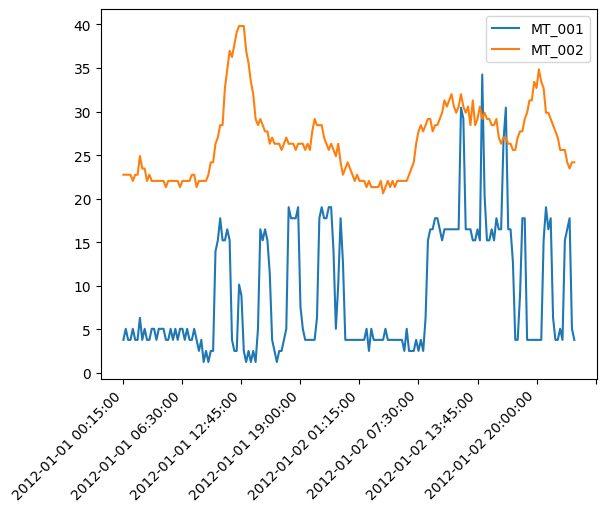

In [11]:
data_example = data.loc['2012-01-01 00:15:00':'2012-01-03 00:00:00'][['MT_001','MT_002']]

data_example.plot()
plt.xticks(rotation=45, ha="right", fontsize=10)   ## rotate x-axis labels, and set their horizontal alignment and font size
plt.show()

#### We quickly note that the main difference between the curves is the level (also seen on the means in df.describe()), so we know we will have to somehow normalize the curves, in order for the clustering technique to capture the behaviour of the consumption throughout the day, rather than the overall level.

### Data for the analysis

We focus on 2013 and 2014 because these are the years with lower number of clients having zero demand

In [12]:
data2011 = data.loc['2011-01-01 00:15:00':'2012-01-01 00:00:00']
data2012 = data.loc['2012-01-01 00:15:00':'2013-01-01 00:00:00']
data2013 = data.loc['2013-01-01 00:15:00':'2014-01-01 00:00:00']
data2014 = data.loc['2014-01-01 00:15:00':'2015-01-01 00:00:00']

In [13]:
# Check number of days
print(data2011.shape[0]/96)
print(data2012.shape[0]/96)
print(data2013.shape[0]/96)
print(data2014.shape[0]/96)

365.0
366.0
365.0
365.0


In [14]:
# See number of clients with 0 demand per year
print(sum(data2011.mean()==0))
print(sum(data2012.mean()==0))
print(sum(data2013.mean()==0))
print(sum(data2014.mean()==0))

210
37
21
1


In [ ]:
clients = data2011.columns
clients_no_demand = clients[data2013.mean()==0] # clients with 0 demand
data_13_14 = data2013.append(data2014) # appending 2013 and 2014
data_13_14 = data_13_14.drop(clients_no_demand, axis=1) # drop clients with 0 demand
print(data_13_14.shape)
print(sum(data_13_14.mean()==0)) # check that there are no clients with 0 demand

rewrite above code

In [16]:
# *** identify clients with 0 demand in 2013, and drop them from the combined 2013-2014 dataset
clients = data2011.columns
data_13_14 = pd.concat([data2013, data2014], axis=0)  # appending 2013 and 2014,  append method is deprecated, use concat instead
clients_no_demand = data_13_14.columns[data_13_14.mean() == 0]  # clients with 0 demand
data_13_14 = data_13_14.drop(clients_no_demand, axis=1) # drop clients with 0 demand
print(data_13_14.shape)   # *** check the shape of the combined dataset after dropping clients with 0 demand
print("checking if there's any client with 0 demand:", sum(data_13_14.mean()==0))   # check that there are no clients with 0 demand

(70080, 369)
checking if there's any client with 0 demand: 0


## Getting average curves per client

In [17]:
data = data_13_14.copy() # weekdays weekends, data2011, data2012, data2013, data2014

In [18]:
data['hour'] = data.index.map(lambda x: x[11:])

In [19]:
data.head(3)

,MT_001,MT_002,MT_003,MT_004,MT_005,MT_006,MT_007,MT_008,MT_009,MT_010,...,MT_362,MT_363,MT_364,MT_365,MT_366,MT_367,MT_368,MT_369,MT_370,hour
2013-01-01 00:15:00,2.538071,22.759602,2.606429,138.211382,63.414634,255.952381,4.522329,239.057239,57.692308,78.494624,...,22300.0,886.075949,1000.000000,16.949153,6.436513,616.330114,76.794658,731.671554,8086.486486,00:15:00
2013-01-01 00:30:00,1.269036,22.759602,2.606429,138.211382,63.414634,264.880952,5.652911,228.956229,57.692308,76.344086,...,21000.0,864.978903,909.090909,18.252934,3.510825,564.530290,76.794658,727.272727,8086.486486,00:30:00
2013-01-01 00:45:00,2.538071,22.759602,2.606429,134.146341,60.975610,250.000000,5.652911,239.057239,54.195804,76.344086,...,18200.0,860.759494,840.909091,16.949153,5.851375,590.869183,68.447412,730.205279,7848.648649,00:45:00


### Getting average curves per client

In [20]:
datagrouped = data.groupby("hour")
average_curves = datagrouped.agg("mean")
average_curves.shape 
average_curves.head(3)   # *** check that the average curves are correct, and that the hours are in the correct order (00:15, 00:30, ..., 23:45)

,MT_001,MT_002,MT_003,MT_004,MT_005,MT_006,MT_007,MT_008,MT_009,MT_010,...,MT_361,MT_362,MT_363,MT_364,MT_365,MT_366,MT_367,MT_368,MT_369,MT_370
hour,,,,,,,,,,,,,,,,,,,,,
00:00:00,5.008344,26.045909,1.938755,130.551843,60.374206,191.136660,7.772366,242.027582,51.585401,54.837237,...,119.625903,36306.438356,1333.223513,1652.677460,37.831080,16.499275,676.790504,148.683880,799.235729,17333.891151
00:15:00,4.917947,25.833512,1.911381,125.863125,57.586034,179.297130,7.426996,232.516950,50.016764,53.424658,...,119.540837,32137.534247,979.064794,1443.711083,33.942955,16.580232,659.875882,155.464587,795.100028,17466.227323
00:30:00,4.984007,24.754964,1.909001,121.566990,55.476111,171.554958,7.179972,225.317098,48.843280,52.514361,...,111.557303,27249.178082,938.598925,1324.501868,31.044275,15.940589,655.911819,153.879754,777.630258,17605.301740


#### The dataframe average_curves contains the 349 typical weekday electric demands

#### We now divide each curve by its mean, so that all curves have mean 1

In [21]:
# *** normalize data by dividing by the mean of each column
# *** so that all clients are on the same scale (otherwise, K-means will cluster clients with high demand together, and clients with low demand together, 
# *** without looking at the shape of their curves)
average_curves_norm = average_curves/(average_curves.mean())  
average_curves_norm.head(3)   # *** validate the normalization 

,MT_001,MT_002,MT_003,MT_004,MT_005,MT_006,MT_007,MT_008,MT_009,MT_010,...,MT_361,MT_362,MT_363,MT_364,MT_365,MT_366,MT_367,MT_368,MT_369,MT_370
hour,,,,,,,,,,,,,,,,,,,,,
00:00:00,0.964792,0.926674,0.991800,1.140106,1.186498,1.008914,1.170686,0.946572,0.983915,0.948867,...,0.414676,0.748555,0.561491,0.430085,0.471574,1.358632,1.215272,1.170441,0.974307,0.992967
00:15:00,0.947378,0.919117,0.977796,1.099159,1.131703,0.946419,1.118666,0.909376,0.953996,0.924425,...,0.414381,0.662602,0.412336,0.375704,0.423108,1.365299,1.184899,1.223818,0.969266,1.000548
00:30:00,0.960104,0.880744,0.976579,1.061641,1.090238,0.905552,1.081459,0.881217,0.931614,0.908674,...,0.386706,0.561815,0.395294,0.344682,0.386975,1.312627,1.177781,1.211343,0.947969,1.008515


#### Plot the first 2 and last 2 clients

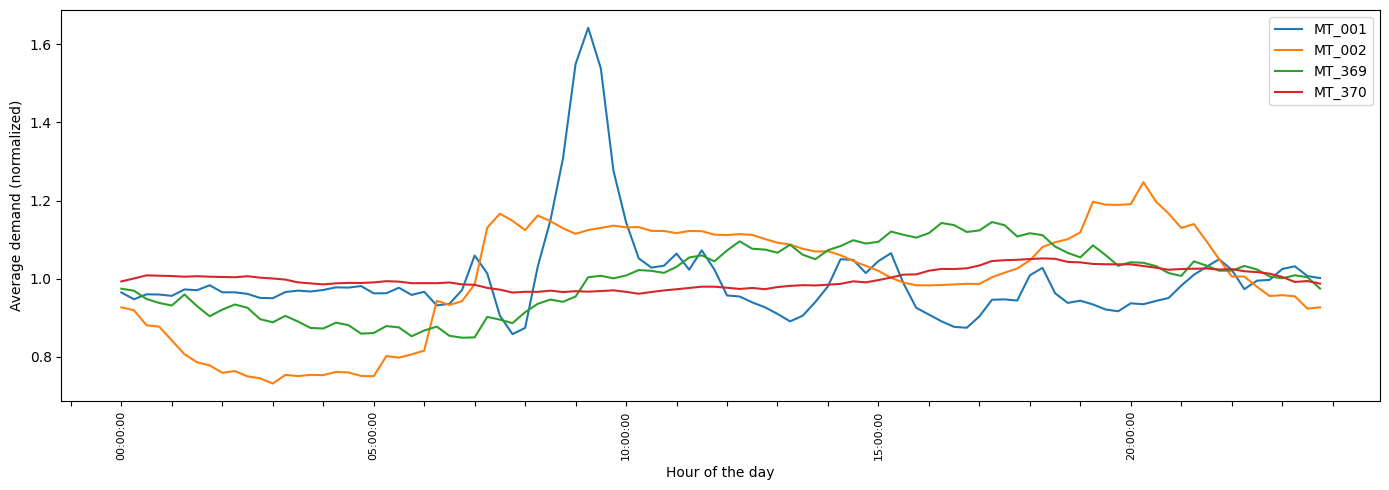

In [22]:
# *** stretch the x-axis so that the 24 hours are more visible, and rotate x-axis labels so that they fit better
plt.figure(figsize=(14, 5))
# --- X-AXIS: EVERY 1 HOUR ---
ax = plt.gca()

#average_curves_norm[['MT_001','MT_002','MT_369','MT_370']].plot()
average_curves_norm[['MT_001','MT_002','MT_369','MT_370']].plot(ax=ax)    # *** specify the axis to plot on, so that we can modify the x-axis ticks
# 4 intervals = 1 hour (4 * 15 mins)
ax.xaxis.set_major_locator(plt.MultipleLocator(4))

# Rotate 90 degrees (vertical) and use smaller font so 24 labels fit perfectly
plt.xticks(rotation=90, ha="center", fontsize=8)
plt.ylabel("Average demand (normalized)")
plt.xlabel("Hour of the day")
plt.tight_layout()   # *** use tight_layout to prevent labels from being cut off

plt.show()

## Clustering Analysis on the average normizalied curves

In [23]:
X = average_curves_norm.copy()
# *** transpose the data so that each client is a row, and each column is an hour of the day (instead of the opposite)
X = np.array(X.T) # put it on the right format
# *** validate array shape and values
print(X.shape)   # should be (number of clients, 96)
print(X[:5, :5]) # print the first 5 rows and 5 columns

(369, 96)
[[0.96479215 0.94737834 0.96010381 0.95943405 0.95608524]
 [0.92667365 0.91911689 0.8807438  0.87724274 0.84198941]
 [0.99179969 0.97779638 0.9765787  0.97170799 0.9534428 ]
 [1.14010579 1.09915933 1.0616413  1.03015338 0.97576074]
 [1.1864976  1.13170334 1.0902383  1.0539605  1.0243473 ]]


## Exercise 1:

a. Using the functions described in Module 2, determine what a convenient number of clusters based on _intertia_ and based on _silhouette_. Justify your choice

b. Make a plot for each cluster, that includes:
    - The number of clients in the cluster (you can put this in the title of the plot)
    - All the curves in the cluster
    - The curve corresponding to the centroid of the cluster (make this curve thicker to distinguish it from the individual curves)
    
You can do 2 separate plots for each cluster if you prefer (one for the individual curves, one for the centroid)

### Answer to Exercise 1.a

Best K: 4, Silhouette Score: 0.4176


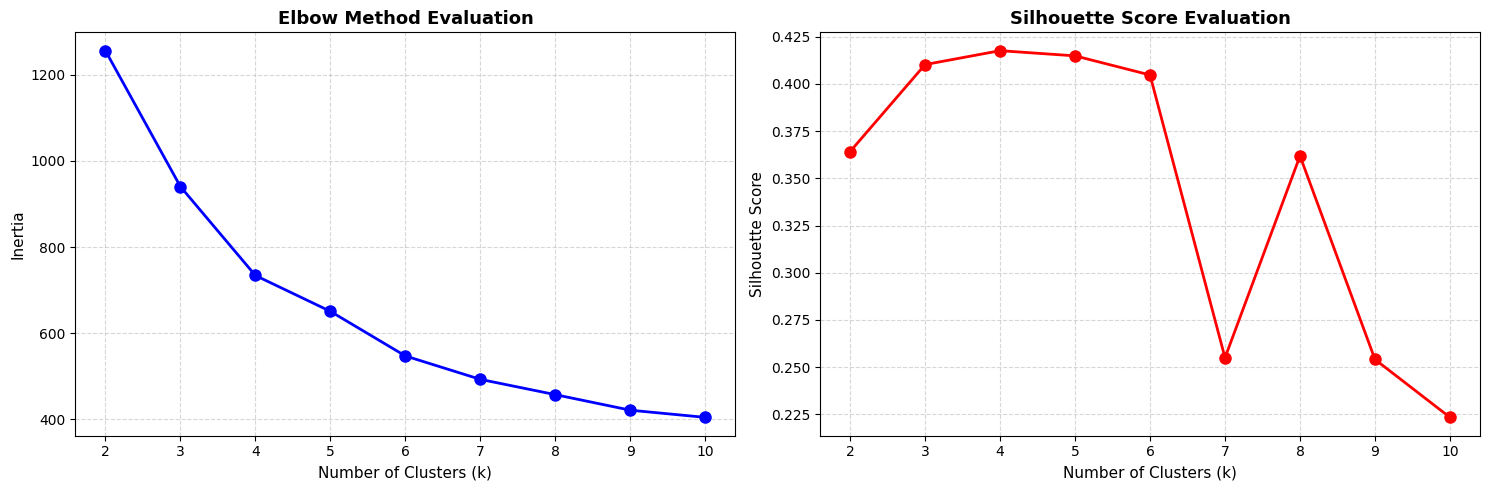

In [28]:
k_range = range(2, 11)   # *** setup clusters from 2 to 10 
inertias = []
silhouette_scores = []

for k in k_range:
    kmeans = KMeans(n_clusters=k, init="k-means++", random_state=42, n_init=10)
    kmeans.fit(X)
    inertias.append(kmeans.inertia_)   # *** append inertia to the list for the Elbow method
    silhouette_scores.append(silhouette_score(X, kmeans.labels_))


# *** printout best silhouette scores
best_score_K = max(silhouette_scores)
best_k = k_range[silhouette_scores.index(best_score_K)]
print(f"Best K: {best_k}, Silhouette Score: {best_score_K:.4f}")

# *** Plot the evaluation metrics side-by-side
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

# *** figure1-1 Elbow Method (Inertia)
ax1.plot(k_range, inertias, "bo-", markersize=8, linewidth=2)   # *** plot inertia with blue circles and lines
ax1.set_xlabel("Number of Clusters (k)", fontsize=11)
ax1.set_ylabel("Inertia", fontsize=11)
ax1.set_title("Elbow Method Evaluation", fontsize=13, fontweight="bold")
ax1.set_xticks(k_range)
ax1.grid(True, linestyle="--", alpha=0.5)

# *** figure1-2 Silhouette Coefficient
ax2.plot(k_range, silhouette_scores, "ro-", markersize=8, linewidth=2)
ax2.set_xlabel("Number of Clusters (k)", fontsize=11)
ax2.set_ylabel("Silhouette Score", fontsize=11)
ax2.set_title("Silhouette Score Evaluation", fontsize=13, fontweight="bold")
ax2.set_xticks(k_range)
ax2.grid(True, linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()



### Justification for the Chosen Number of Clusters (K):
Based on the evaluation metrics generated above, $K = 4$ is selected as the most convenient number of clusters.
#### Inertia (Elbow Method): 
In the Inertia plot we look for an inflection point or "elbow" where the drop slow down. A sharp drop is visible from $K=3$ to $K=4$. Beyond $K=4$, the rate of decrease slows down drastically,  meaning adding more clusters beyond K=4 doesn't help much..
#### Silhouette Coefficient: 
The Silhouette Score measures how cleanly our groups are separated. Our plot peaks clearly at $K = 4$. This shows that a 4-cluster setup creates the most distinct and tightly packed groups.

Because both independent mathematical criteria (Inertia and Silhouette) cleanly converge on the exact same value, $K = 4$ represents the ideal balance between low complexity and descriptive accuracy.

### Anwser to Exercise 1.b
plot the data for each cluster

['00:00', '00:15', '00:30', '00:45', '01:00', '01:15', '01:30', '01:45', '02:00', '02:15', '02:30', '02:45', '03:00', '03:15', '03:30', '03:45', '04:00', '04:15', '04:30', '04:45', '05:00', '05:15', '05:30', '05:45', '06:00', '06:15', '06:30', '06:45', '07:00', '07:15', '07:30', '07:45', '08:00', '08:15', '08:30', '08:45', '09:00', '09:15', '09:30', '09:45', '10:00', '10:15', '10:30', '10:45', '11:00', '11:15', '11:30', '11:45', '12:00', '12:15', '12:30', '12:45', '13:00', '13:15', '13:30', '13:45', '14:00', '14:15', '14:30', '14:45', '15:00', '15:15', '15:30', '15:45', '16:00', '16:15', '16:30', '16:45', '17:00', '17:15', '17:30', '17:45', '18:00', '18:15', '18:30', '18:45', '19:00', '19:15', '19:30', '19:45', '20:00', '20:15', '20:30', '20:45', '21:00', '21:15', '21:30', '21:45', '22:00', '22:15', '22:30', '22:45', '23:00', '23:15', '23:30', '23:45']


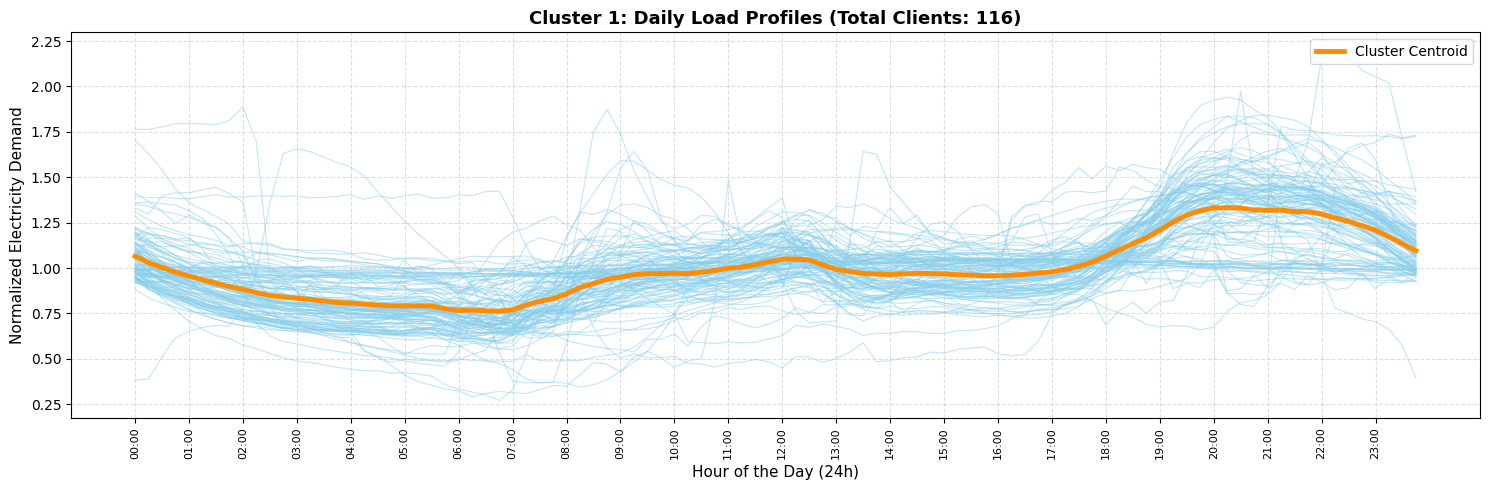

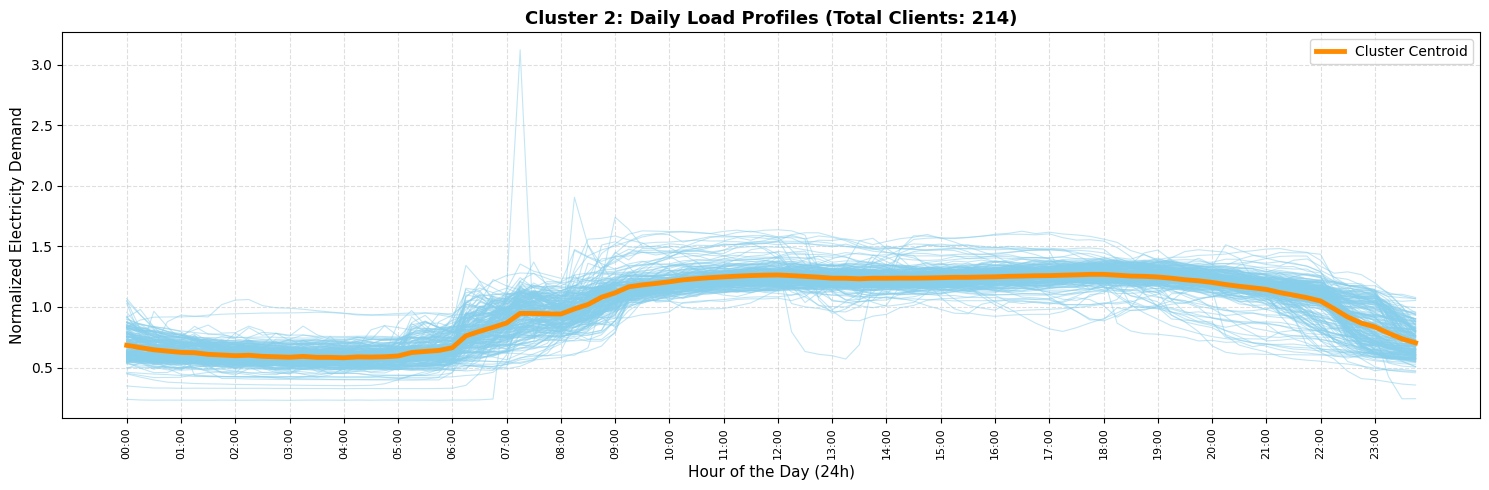

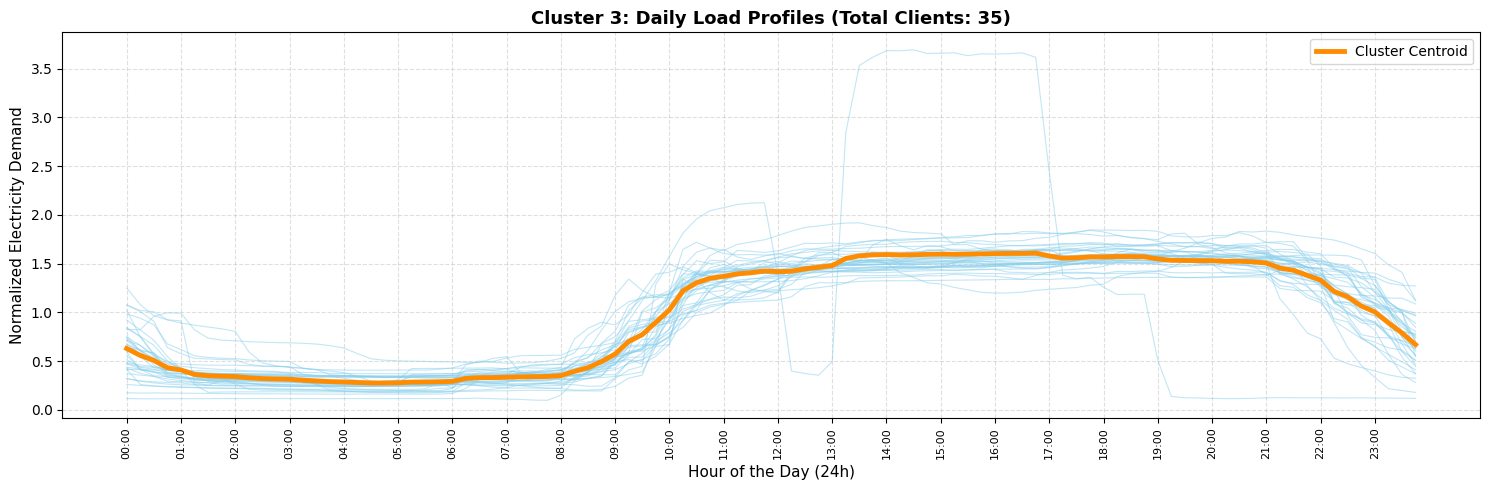

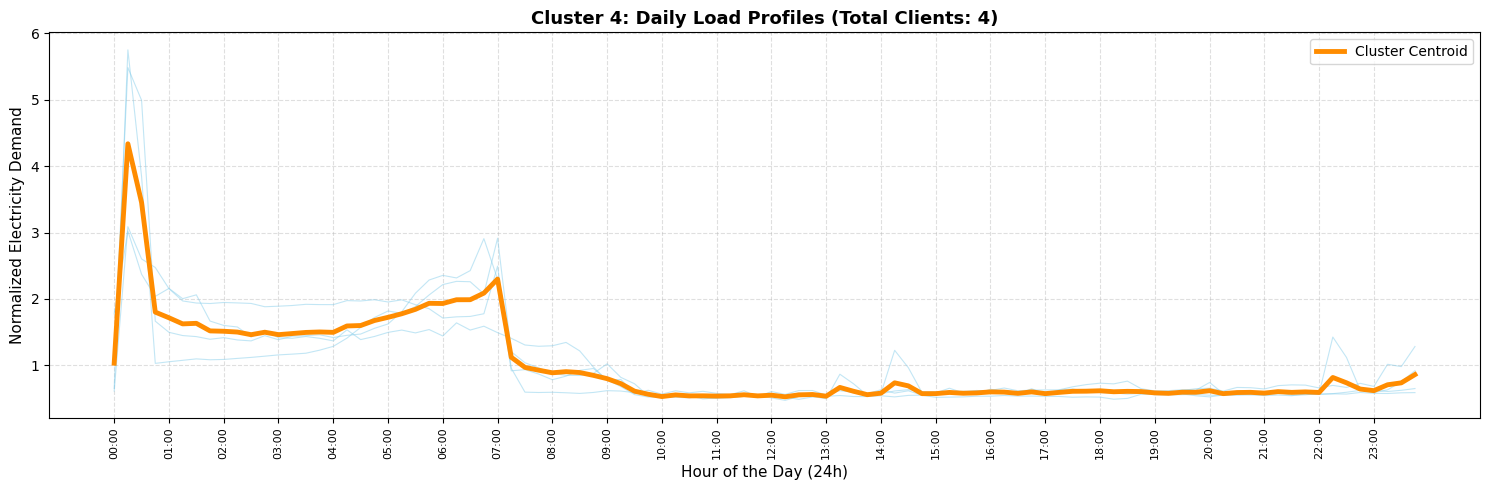

In [30]:
# *** from above evaluation, we can see that k=3 is a good choice (elbow point in inertia, and high silhouette score)
k_optimal = 4

kmeans_final = KMeans(
    n_clusters=k_optimal, init="k-means++", random_state=42, n_init=10
)
cluster_labels = kmeans_final.fit_predict(X)
centroids = kmeans_final.cluster_centers_
# *** extract the clean time labels (00:00, 00:15, ..., 23:45) from the index of average_curves_norm, and store them in a list
clean_time_axis = [str(t)[:5] for t in average_curves_norm.index]
print(clean_time_axis)  # *** check that the clean time axis is correct, and that it matches the x-axis labels in the plot

# Loop through each cluster and generate separate graphs
for cluster_id in range(k_optimal):
    plt.figure(figsize=(15, 5))
    ax = plt.gca()

    # Isolate client data belonging to the current cluster group
    client_curves_in_cluster = X[cluster_labels == cluster_id]
    num_clients = client_curves_in_cluster.shape[0]

    # *** plot all client curves in the cluster with thin lines and light color
    plt.plot(
        range(len(clean_time_axis)),
        client_curves_in_cluster.T,       # *** transpose so that each client's curve is plotted correctly
        color="skyblue",
        alpha=0.5,
        linewidth=0.8,
    )

    # *** plot the cluster centroid with a thick line and a distinct color
    plt.plot(
        range(len(clean_time_axis)),
        centroids[cluster_id],
        color="darkorange",
        linewidth=3.5,
        label="Cluster Centroid",
    )

    # *** get hours labels
    tick_positions = list(range(0, len(clean_time_axis), 4))

    # *** map the tick positions to the corresponding time labels using a list comprehension
    tick_labels = [clean_time_axis[i] for i in tick_positions]

    # *** bind the numeric tick positions to the string labels, and rotate them for better readability
    plt.xticks(
        ticks=tick_positions,
        labels=tick_labels,
        rotation=90,
        ha="center",
        fontsize=8,
    )

    # Labels, Legends, and Styling
    plt.title(
        f"Cluster {cluster_id + 1}: Daily Load Profiles (Total Clients: {num_clients})",
        fontsize=13,
        fontweight="bold",
    )
    plt.xlabel("Hour of the Day (24h)", fontsize=11)
    plt.ylabel("Normalized Electricity Demand", fontsize=11)
    plt.legend(loc="upper right")
    plt.grid(True, linestyle="--", alpha=0.4)

    plt.tight_layout()
    plt.show()

## Exercises 2

In this exercise you work with the daily curves of 1 single client.

First you create a list of arrays, each array containing a normalized curve for a day. The list contains 730 arrays, one for each of the days of 2013 and 2014.

a. Determine the optimal value for k-means. 

b. What are the clusters that you obtained represent?

In [31]:
client = 'MT_022'
oneClient = data_13_14[client]
X = [] # a list of arrays, each array being a normalized curve for a day
for J in range(2*365):
    X.extend([np.array(oneClient[J*96:(J+1)*96])])#/np.mean(oneClient[J*96:(J+1)*96])]) 

### Answer to Exercise 2.a

##### Pick one client and normalize the data

Final matrix shape: (730, 96)


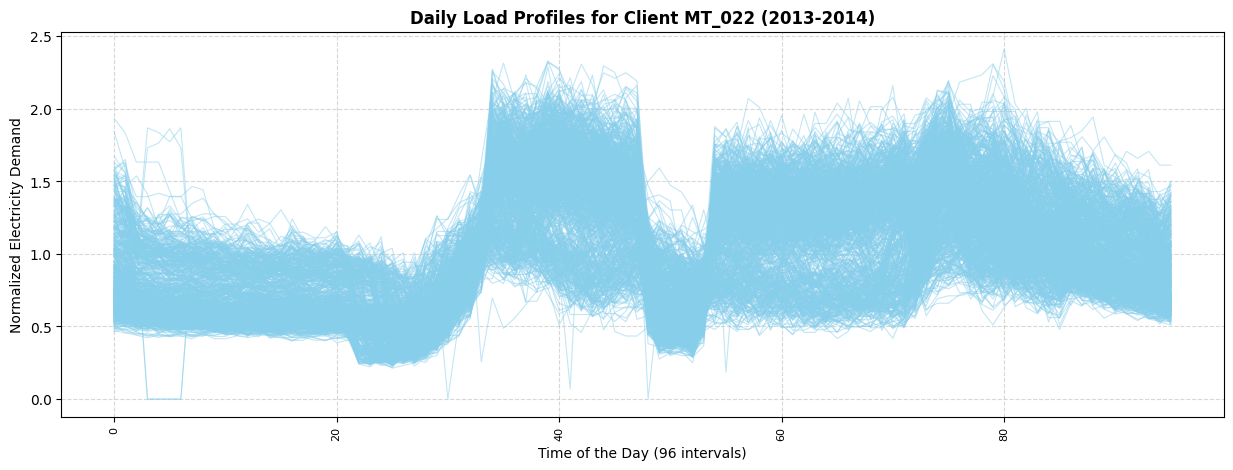

In [32]:
# *** take client MT_022 as an example, and run K-means on this single client(2013 and 2014)
client = 'MT_022'
oneClient = data[client]
#oneClient.head(3)
oneClient.shape
# *** normalize the data
X_matrix = []  # *** initialize an empty list to store the normalized daily curves

# *** use oneClient.values to ensure we are working with a numpy array
oneClient_values = oneClient.values

for J in range(2 * 365):
    # *** get the 96 values for the current day (J) using slicing, and store them in day_data
    day_data = oneClient_values[J * 96 : (J + 1) * 96]

    # *** calculate the mean of the day_data, which will be used for normalization
    day_mean = np.mean(day_data)

    # *** normalize the day_data by dividing by the mean, but only if the mean is greater than 0 to avoid division by zero
    if day_mean > 0:
        normalized_day = day_data / day_mean
    else:
        normalized_day = day_data  # *** if the mean is 0, keep the original values (which are likely all 0)

    # *** append the normalized daily curve to the X_matrix list
    X_matrix.append(normalized_day)

# *** transform the list of arrays into a 2D numpy array (matrix) where each row is a normalized daily curve
X_matrix = np.array(X_matrix)
print("Final matrix shape:", X_matrix.shape)  
# *** plot the data
plt.figure(figsize=(15, 5))
ax = plt.gca()
plt.plot(X_matrix.T, color="skyblue", alpha=0.5, linewidth= 0.8)  # *** plot all daily curves with thin lines and light color
plt.xticks(rotation=90, ha="center", fontsize=8)  # *** rotate x-axis labels and set their horizontal alignment and font size
plt.ylabel("Normalized Electricity Demand")
plt.xlabel("Time of the Day (96 intervals)")
plt.title("Daily Load Profiles for Client " + client + " (2013-2014)", fontsize=12, fontweight="bold")
plt.grid(True, linestyle="--", alpha=0.5)
plt.show()



##### Evaluate inertia and silouette score

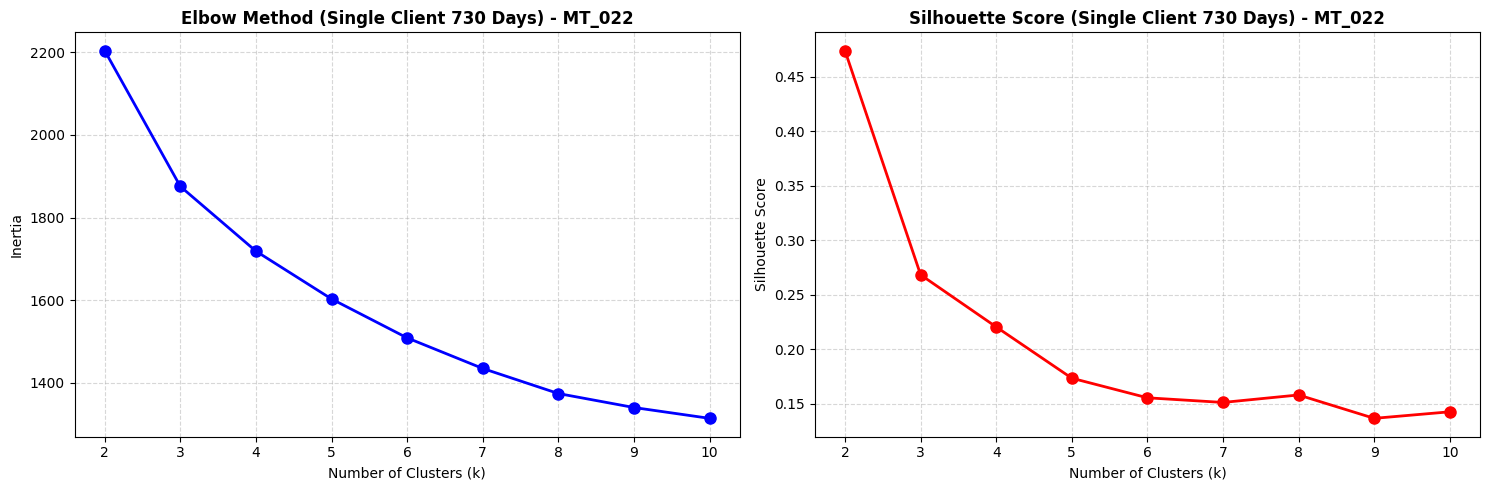

Best K: 2, Best Silhouette Score: 0.4736
Best K: 2, Inertia: 2203.5729


In [33]:
# *** define clustering evaluation range
k_range_single = range(2, 11)
inertias_single = []
silhouette_scores_single = []

# *** pass the X_matrix (normalized daily curves) to K-means
# *** run loop to evaluate K-means for different k values, and store the inertia and silhouette scores for each k
for k in k_range_single:
    kmeans = KMeans(
        n_clusters=k, init="k-means++", random_state=42, n_init=10
    )
    kmeans.fit(X_matrix)
    inertias_single.append(kmeans.inertia_)
    silhouette_scores_single.append(silhouette_score(X_matrix, kmeans.labels_))

# *** plot the evaluation metrics side-by-side for the single client
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

# *** figure1-1 Elbow Method (Inertia)
ax1.plot(k_range_single, inertias_single, "bo-", markersize=8, linewidth=2)
ax1.set_title("Elbow Method (Single Client 730 Days) - "+ client, fontsize=12, fontweight="bold")
ax1.set_xlabel("Number of Clusters (k)", fontsize=10)
ax1.set_ylabel("Inertia", fontsize=10)
ax1.grid(True, linestyle="--", alpha=0.5)

# *** figure1-2 Silhouette Score
ax2.plot(k_range_single, silhouette_scores_single, "ro-", markersize=8, linewidth=2)
ax2.set_title("Silhouette Score (Single Client 730 Days) - "+ client, fontsize=12, fontweight="bold")
ax2.set_xlabel("Number of Clusters (k)", fontsize=10)
ax2.set_ylabel("Silhouette Score", fontsize=10)
ax2.grid(True, linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()

# *** printout silhouette scores for k=2 to 10, and find the optimal k for this single client
best_score = max(silhouette_scores_single)
best_k = k_range_single[silhouette_scores_single.index(best_score)]
print(f"Best K: {best_k}, Best Silhouette Score: {best_score:.4f}")

best_inertia = inertias_single[silhouette_scores_single.index(best_score)]
print(f"Best K: {best_k}, Inertia: {best_inertia:.4f}")

### Justification
Based on the experimental visualization for client MT_022, the optimal number of clusters is determined to be $K = 2$.
1. Silhouette Score Peak: The Silhouette Score curve reaches its global maximum at $K = 2$. 
2. Elbow Method Consistency: The Inertia curve displays a steady, monotonic decline, but the most mathematically justifiable and distinct partition that aligns with the highest silhouette performance is at $K = 2$.  

Therefore, $K = 2$ is chosen as the optimal value to segment this single client's 730 days of consumption data into two dominant temporal behavioral patterns.

### Answer to Exercise 2.b

### clustering the data based on selected K

Pattern (Cluster)    | Actual Weekdays | Actual Weekends | Total Days
--------------------------------------------------------------------------------
Pattern 1            | 55              | 156             | 211       
Pattern 2            | 467             | 52              | 519       


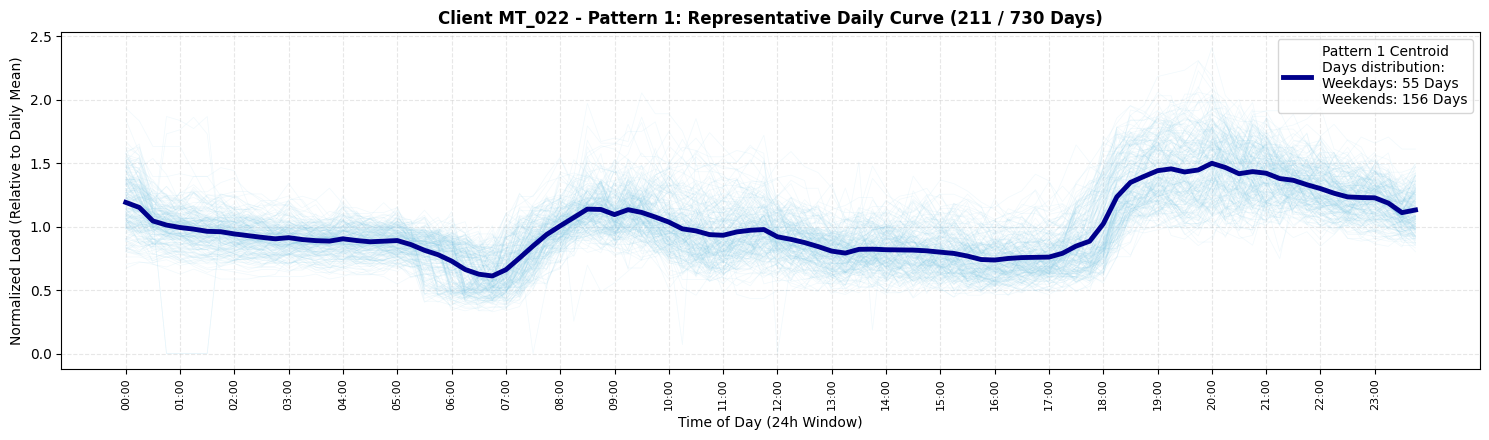

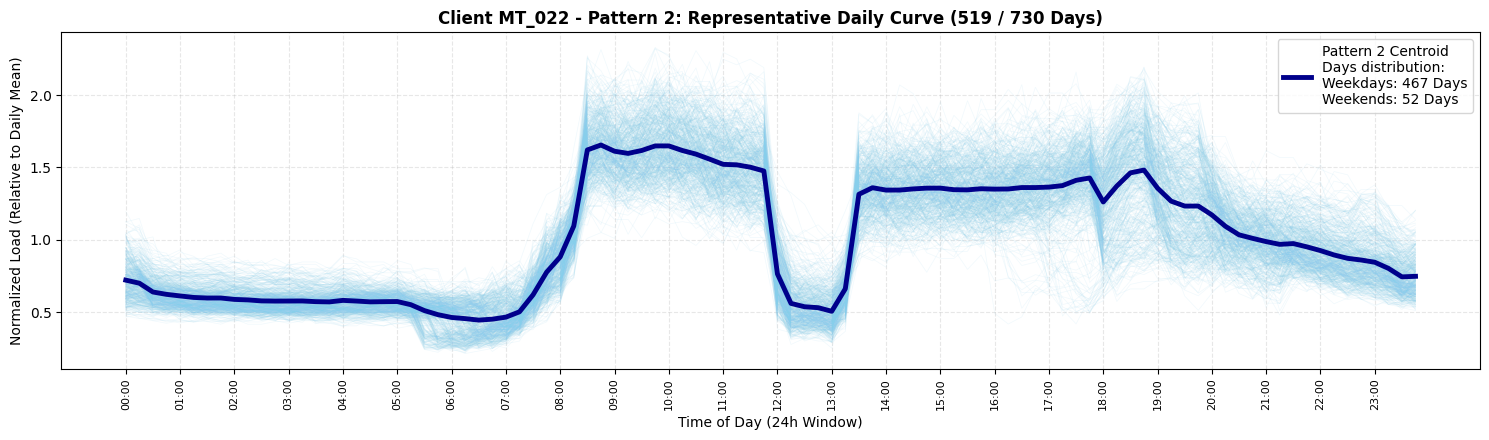

In [34]:
# *** from the evaluation, we can see that k=2 is a good choice for this single client (high silhouette score, and elbow point in inertia)
k_optimal = best_k
kmeans_final = KMeans(
    n_clusters=k_optimal, init="k-means++", random_state=42, n_init=10
)
day_labels = kmeans_final.fit_predict(X_matrix)
centroids = kmeans_final.cluster_centers_

#=================================================================
# print weekday/weekend distribution for each pattern (cluster)
#=================================================================
# *** extract real dates for the 730 days, and determine which ones are weekdays and which ones are weekends
all_days_timestamps = pd.to_datetime(data.index[::96])
# *** build a boolean array: True for Saturday/Sunday, False for Monday-Friday
is_weekend = all_days_timestamps.dayofweek >= 5

# *** format printout for weekday/weekend distribution
print("=" * 80)
print(f"{'Pattern (Cluster)':<20} | {'Actual Weekdays':<15} | {'Actual Weekends':<15} | {'Total Days':<10}")
print("-" * 80)

# *** create a dictionary to store the counts for each pattern
pattern_counts = {}
for cluster_id in range(k_optimal):
    # *** get the indices of the days that belong to the current cluster
    cluster_indices = np.where(day_labels == cluster_id)[0]

    # *** calculate how many of those days are actually weekdays and weekends
    n_weekends = np.sum(is_weekend[cluster_indices])
    n_weekdays = len(cluster_indices) - n_weekends
    n_total = len(cluster_indices)

    # *** store the counts in the dictionary
    pattern_counts[cluster_id] = {
        "weekdays": n_weekdays,
        "weekends": n_weekends,
        "total": n_total,
    }

    # *** print the counts of weekdays, weekends, and total days for the current pattern
    print(
        f"Pattern {cluster_id + 1:<12} | {n_weekdays:<15} | {n_weekends:<15} | {n_total:<10}"
    )

print("=" * 80)

# *** loop through each cluster and generate separate graphs for the single client
for cluster_id in range(k_optimal):
    plt.figure(figsize=(15, 4.5))

    # *** extract the daily curves that belong to the current cluster, and count how many days are in this cluster
    days_in_cluster = X_matrix[day_labels == cluster_id]
    num_days = days_in_cluster.shape[0]

    #======================================================
    current_weekdays = pattern_counts[cluster_id]["weekdays"]
    current_weekends = pattern_counts[cluster_id]["weekends"]
    current_total = pattern_counts[cluster_id]["total"]
    #=====================================================

    days_distribution = f"Weekdays: {current_weekdays} Days\nWeekends: {current_weekends} Days"

    # *** plot all daily curves in the cluster with thin lines and light color
    plt.plot(
        range(96),
        days_in_cluster.T,
        color="skyblue",
        alpha=0.12,
        linewidth=0.5,
    )

    # *** plot the centroid line (dark blue), representing the "absolute average" of the pattern
    plt.plot(
        range(96),
        centroids[cluster_id],
        color="darkblue",
        linewidth=3.5,
        label=f"Pattern {cluster_id + 1} Centroid \nDays distribution: \n{days_distribution}"
    )

    # *** set the x-axis ticks and labels (every 4 points, i.e., every hour)
    tick_positions = list(range(0, 96, 4))
    tick_labels = [clean_time_axis[i] for i in tick_positions]
    plt.xticks(
        ticks=tick_positions,
        labels=tick_labels,
        rotation=90,
        ha="center",
        fontsize=8,
    )

    # *** chart decoration and enhancement
    plt.title(
        f"Client {client} - Pattern {cluster_id + 1}: Representative Daily Curve ({num_days} / 730 Days)",
        fontsize=12,
        fontweight="bold",
    )
    plt.xlabel("Time of Day (24h Window)", fontsize=10)
    plt.ylabel("Normalized Load (Relative to Daily Mean)", fontsize=10)
    plt.grid(True, linestyle="--", alpha=0.3)
    plt.legend(loc="upper right")
    plt.tight_layout()
    plt.show()

#### Justification  
The two clusters obtained through K-means successfully uncover the electricity demand behavior of client **MT_022** across the 730-day timeline:

1. **Cluster 1 Represents "Rest Days & Weekends" (~200+ Days):**
   This pattern represents Saturdays, Sundays, and public holidays. On these days, power use stays low and flat. The typical morning surge is delayed because people sleep in, and businesses or offices are closed.
2. **Cluster 2 Represents "Standard Workdays" (~500+ Days):**
   This pattern represents normal Monday-to-Friday workdays. Power use spikes sharply around 7:00–8:00 AM, stays high all day during business hours, and drops after 6:00 PM (18:00) when people head home.


---

#### The following cell generates a list of all the days in the two years 2013-2014, which is helpful to answer part (b)

In [232]:
from datetime import date, timedelta

d1 = date(2013, 1, 1)  # start date
d2 = date(2014, 12, 31)  # end date
delta = d2 - d1         # timedelta
daysyear = []
D = {0:'mon', 1:'tue', 2:'wed', 3:'thu', 4:'fri', 5:'sat', 6:'sun'}
for i in range(delta.days + 1):
    daysyear.extend([D[(d1 + timedelta(days=i)).weekday()]+"-"+str(d1 + timedelta(days=i))])

#### The following cell shows you how to do the following: given a list L, and a list of booleans B (True, False), get the sublist of L that corresponds to the True values in B. For example if L=[1,2,3,4] and B=[False,True,True,False], then the results is [2,3]. This is also helpful for pard (b)

In [233]:
from itertools import compress
L = [1,2,3,4]
B = [False, True, True, False]
list(compress(L, B))

[2, 3]